In [7]:
import tifffile
import imageio.v2 as imageio
import numpy as np

path = "3D_noise_air.tif"
volume = tifffile.imread(path)  # shape: (N, H, W)

slice_idx = 244  # or your chosen number
noisy = volume[slice_idx]

# normalize to 0–255 for PNG
img = noisy - noisy.min()
img = img / (img.max() + 1e-8)
img = (img * 255).astype("uint8")

imageio.imwrite("examples/n2v_noisy.png", img)
print("Saved noisy slice to examples/n2v_noisy.png")


Saved noisy slice to examples/n2v_noisy.png


In [14]:
denoised = n2v_model.predict(noisy[None, ..., None], axes='SYXC')[0, ..., 0]

# normalize
d = denoised - denoised.min()
d = d / (d.max() + 1e-8)
d = (d * 255).astype("uint8")

imageio.imwrite("examples/n2v_denoised.png", d)
print("Saved denoised slice to examples/n2v_denoised.png")

The input image is of type uint8 and will be casted to float32 for prediction.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Saved denoised slice to examples/n2v_denoised.png


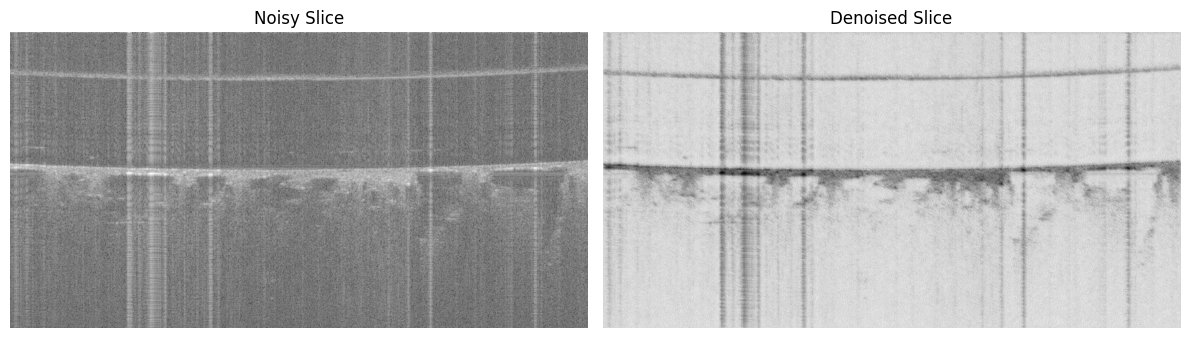

In [16]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio

noisy_img_path = "examples/n2v_noisy.png"
denoised_img_path = "examples/n2v_denoised.png"

noisy_image = imageio.imread(noisy_img_path)
denoised_image = imageio.imread(denoised_img_path)

plt.figure(figsize=(12, 6)) # Adjust figure size as needed

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.imshow(noisy_image, cmap='gray')
plt.title("Noisy Slice")
plt.axis('off')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.imshow(denoised_image, cmap='gray')
plt.title("Denoised Slice")
plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

### Noisy Image

In [ ]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio

noisy_img_path = "examples/n2v_noisy.png"
noisy_image = imageio.imread(noisy_img_path)

plt.figure(figsize=(8, 6))
plt.imshow(noisy_image, cmap='gray')
plt.title("Noisy Slice")
plt.axis('off')
plt.show()

### Denoised Image

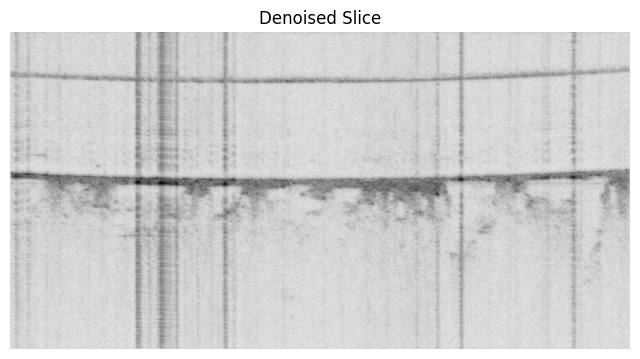

In [15]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio

denoised_img_path = "examples/n2v_denoised.png"
denoised_image = imageio.imread(denoised_img_path)

plt.figure(figsize=(8, 6))
plt.imshow(denoised_image, cmap='gray')
plt.title("Denoised Slice")
plt.axis('off')
plt.show()

In [11]:
pip install n2v

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 29.9 MB/s eta 0:00:00


In [18]:
import numpy as np

# Assuming 'difference_image' is already computed from the previous step
# If not, ensure the cell that calculates it (e.g., 5333a537) has been run.

if 'difference_image' in locals():
    min_diff = np.min(difference_image)
    max_diff = np.max(difference_image)
    mean_diff = np.mean(difference_image)
    median_diff = np.median(difference_image)
    std_diff = np.std(difference_image)

    print(f"Difference Image Statistics:")
    print(f"  Minimum Absolute Difference: {min_diff:.2f}")
    print(f"  Maximum Absolute Difference: {max_diff:.2f}")
    print(f"  Mean Absolute Difference:    {mean_diff:.2f}")
    print(f"  Median Absolute Difference:  {median_diff:.2f}")
    print(f"  Standard Deviation:        {std_diff:.2f}")
elif 'noisy_image' in locals() and 'denoised_image' in locals():
    # Recalculate if difference_image is not directly available but components are
    difference_image = np.abs(noisy_image - denoised_image)
    min_diff = np.min(difference_image)
    max_diff = np.max(difference_image)
    mean_diff = np.mean(difference_image)
    median_diff = np.median(difference_image)
    std_diff = np.std(difference_image)

    print(f"Difference Image Statistics:")
    print(f"  Minimum Absolute Difference: {min_diff:.2f}")
    print(f"  Maximum Absolute Difference: {max_diff:.2f}")
    print(f"  Mean Absolute Difference:    {mean_diff:.2f}")
    print(f"  Median Absolute Difference:  {median_diff:.2f}")
    print(f"  Standard Deviation:        {std_diff:.2f}")
else:
    print("Error: 'difference_image', 'noisy_image', or 'denoised_image' not found. Please ensure previous steps are executed.")

Difference Image Statistics:
  Minimum Absolute Difference: 0.00
  Maximum Absolute Difference: 251.00
  Mean Absolute Difference:    81.22
  Median Absolute Difference:  86.00
  Standard Deviation:        28.19


### Absolute Difference Between Noisy and Denoised Images

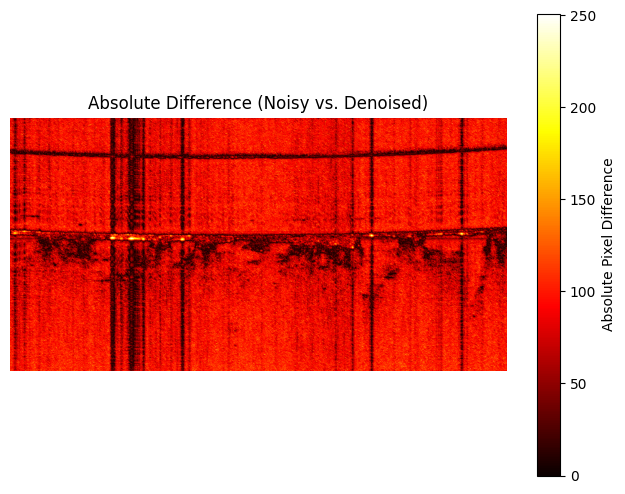

In [19]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import numpy as np

noisy_img_path = "examples/n2v_noisy.png"
denoised_img_path = "examples/n2v_denoised.png"

noisy_image = imageio.imread(noisy_img_path).astype(np.float32)
denoised_image = imageio.imread(denoised_img_path).astype(np.float32)

# Calculate the absolute difference
difference_image = np.abs(noisy_image - denoised_image)

plt.figure(figsize=(8, 6))
plt.imshow(difference_image, cmap='hot') # Using 'hot' colormap to highlight differences
plt.colorbar(label='Absolute Pixel Difference')
plt.title("Absolute Difference (Noisy vs. Denoised)")
plt.axis('off')
plt.show()

The difference image highlights the regions where the denoising model made the most significant changes. Brighter areas indicate larger pixel value differences, corresponding to where the noise was most effectively removed or smoothed out. Conversely, darker areas represent regions where the original noisy image and the denoised image are very similar, suggesting less noise or minimal changes made by the model.

In [13]:
import numpy as np
from n2v.models import N2V, N2VConfig
from csbdeep.models import Config # Retained for potential future use or to avoid immediate deletion if other parts rely on it indirectly

# Assuming a default configuration. You might need to adjust this
# based on your specific image data and training requirements.
# For example, patch_shape, train_steps_per_epoch, and train_epochs
# can be set based on your dataset characteristics.
# The 'noisy' variable is already available from previous execution.

# Create a configuration object
# The input image shape for N2V is typically (H, W, C) or (N, H, W, C).
# Since 'noisy' is (H, W), we'll treat it as (H, W, 1) for grayscale.
# You might need to adjust based on the actual input expected by your N2V model.
# Let's assume a 2D grayscale image for now.

config = N2VConfig(noisy[None, ..., None], # Reshape noisy to (1, H, W, 1) for N2VConfig
                # axes='SYXC', # Removed this parameter as N2VConfig should infer it from X
                unet_kern_size=3,
                n_channel_out=1,
                train_steps_per_epoch=10,
                train_epochs=10,
                train_batch_size=16,
                n2v_perc_pix=0.198,
                n2v_patch_shape=(64, 64),
                # n2v_manipulator='uniform', # Removed this parameter
                # n2v_neighborhood_radius=5, # Removed this parameter
                train_loss='mse',
                batch_norm=True,
                allow_new_parameters=True # Retaining this for other N2V-specific parameters
                )

# Create the N2V model
n2v_model = N2V(config=config, name='n2v_2D_model', basedir='models')

/usr/local/lib/python3.12/dist-packages/n2v/models/n2v_standard.py:447: UserWarning: output path for model already exists, files may be overwritten: /content/models/n2v_2D_model
  warnings.warn(


The `n2v_model` is now initialized. You would typically train this model with your noisy data before using it for prediction. For demonstration, the previous cell sets up a basic model. If you have a pre-trained model, you can load it using `n2v_model.load_weights('path/to/your/weights.h5')`.